# Loan Credit Risk Analysis
### Exploratory Data Analysis (EDA)

This notebook analyzes Lending Club loan data to identify patterns associated with loan default risk.

## Problem Statement

The goal of this analysis is to understand which borrower and loan characteristics are associated with loan default. This will help identify risk factors in lending decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_style("whitegrid")


## 1. Load Dataset

In [ ]:
df = pd.read_csv("../data/processed/cleaned_loans.csv")
df["default"].value_counts()

## 2. Target Variable Analysis (Default Rate)

In [ ]:
df["default"].value_counts(normalize=True)

### Insight
This shows the baseline default rate in the dataset, which is important for understanding class imbalance.

In [ ]:
### Default Distribution
# Approximately X% of loans resulted in default, indicating the baseline risk level in the dataset.

## 3. Data Overview

In [ ]:
df.info()
df.describe()

## 4. Feature Engineering

In [8]:
df["log_income"] = np.log(df["annual_inc"] + 1)
df["dti_group"] = pd.cut(
    df["dti"],
    bins=[0, 10, 20, 30, 100],
    labels=["Low", "Medium", "High", "Very High"]
)

## 5. Risk Factor Analysis (Default vs Features)

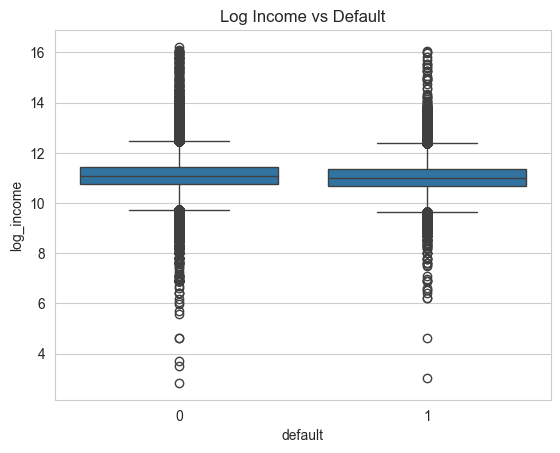

In [9]:
sns.boxplot(x="default", y="log_income", data=df)
plt.title("Log Income vs Default")
plt.show()

### Insight

The plot shows that both defaulted and non-defaulted borrowers have similar median log income and overlapping distributions.
 
This suggests that income alone is not a strong differentiating factor for predicting default in this dataset.

Both groups also contain low-income and high-income outliers, indicating that extreme income values exist regardless of loan outcome. 

Overall, income does not show a clear separation between the two classes.

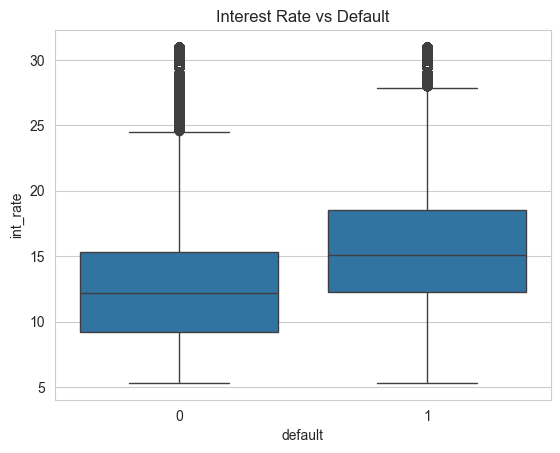

In [18]:
sns.boxplot(x="default", y="int_rate", data=df)
plt.title("Interest Rate vs Default")
plt.show()

### Insight 

The plot shows that defaulted borrowers have a higher median interest rate (~15%) compared to non-defaulted borrowers (~12%).

Notably, both groups share a similar lower whisker (~5%), suggesting that even borrowers with low interest rates might still default.

Overall, as interest rate increases, borrowers are more likely to default.